In [ ]:
# Librerias para la Manipulación de datos y visualización
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns

#LIbreria para pre-procesar datos (antes de entrenar el modelo)
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#Librerias de modelos
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import tree

#Librerias para evaluar modelos
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Cargar base de datos
input_file = "datos_banco2.xlsx"
df1 = pd.read_excel(input_file)
input_file2 = "clientes_Actuales.xlsx"
df4 = pd.read_excel(input_file2)

1. Comprender el negocio

In [ ]:
# ¿Qué tipo de modelo debe realizar?
# Dado que necesitamos predecir si un cliente se va a fugar o no, lo mejor sería realizar un modelo de aprendizaje supervisado, especialmente uno de clasificación.

In [ ]:
# ¿Cuál es su variable target (la variable que debera modelar)?
# La variable target que vamos a modelar es ClienteActual, que nos perimite determinar si es o no cliente del banco.

In [ ]:
# Identifique los datos relevantes de la base de datos que debe utilizar:
# Los datos relevantes que encontramos nosotros para poder ocupar son Score_credito, Ciudad, Genero, Edad, AnosCliente, saldo, Productos, TarjetaCredito, MiembroActivo y SueldoAnual, asi podemos conocer bien a los clientes y en el caso de existir una variable que no sea significativa, luego se puede sustraer.

2) Preparar los datos

In [101]:
# Se transforman las variables, "Ciudad", "Genero", "TarjetaCredito", "MiembroActivo" y "ClienteActual" a variable dummy para que el modelo las pueda procesar.
df1= df1.drop(["Id", "ID_cliente"], axis=1)
df1['Ciudad']= df1['Ciudad'].replace(['Santiago','Concepcion', 'Valparaiso'],['1','2', '3'])
df1['Genero']= df1['Genero'].replace(['Female','Male'],['0','1'])
df1['TarjetaCredito']= df1['TarjetaCredito'].replace(['No','Si'],['0','1'])
df1['MiembroActivo']= df1['MiembroActivo'].replace(['No','Si'],['0','1'])
df1['ClienteActual']= df1['ClienteActual'].replace(['No','Si'],['0','1'])

3) Modelar y evaluar

In [ ]:
# Hacemos la partición de datos y el escalamiento x_train, y_train, x_test, y_test
x=df1.drop(["ClienteActual"], axis=1)
y = df1["ClienteActual"]
# Separamos train de test
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=5)
print(x_train.head(5))
print(x_test.head(5))
# Escalamos data
x_train=scale(x_train)
x_test=scale(x_test)

      Score_credito Ciudad Genero  Edad  AnosCliente   saldo  Productos  \
6824            640      2      1    38            9       0          2   
2638            593      2      1    43            9       0          2   
2019            706      2      1    30            3   98415          1   
8689            542      2      1    67           10  129431          1   
6447            619      1      0    31            3  141751          1   

     TarjetaCredito MiembroActivo  SueldoAnual  
6824              1             0        88827  
2638              1             1        76357  
2019              1             1       110520  
8689              0             1        21343  
6447              0             1        61531  
      Score_credito Ciudad Genero  Edad  AnosCliente   saldo  Productos  \
7177            559      3      0    28            3  152264          1   
5835            609      1      1    37            5  129312          1   
5334            786      3    

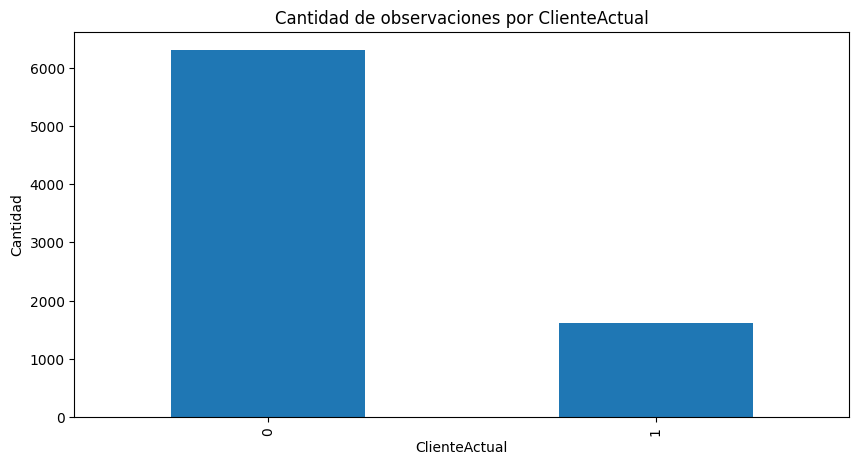

In [ ]:
# Los datos están desbalanceados, por lo que debemos equilibrarlos
fig = plt.figure(figsize = (10, 5))
y_train.value_counts().plot(kind='bar')
plt.xlabel("ClienteActual")
plt.ylabel("Cantidad")
plt.title("Cantidad de observaciones por ClienteActual")
plt.show()

In [104]:
x_train_B, y_train_B = SMOTE().fit_resample(x_train, y_train)

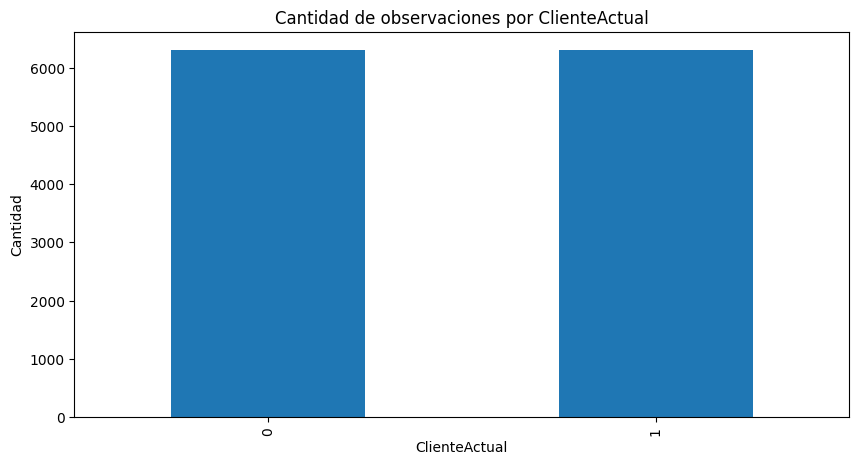

In [ ]:
# Realizar el balance
fig = plt.figure(figsize = (10, 5))
y_train_B.value_counts().plot(kind='bar')
plt.xlabel("ClienteActual")
plt.ylabel("Cantidad")
plt.title("Cantidad de observaciones por ClienteActual")
plt.show()

In [ ]:
# Generar el modelo Regresion Logistica y entrenamos
modelo_LR = LogisticRegression()
modelo_LR.fit(x_train_B, y_train_B)
# Se genera un segundo modelo y se cambia el parámetro "C"
modelo_LR2 = LogisticRegression(C=10)
modelo_LR2.fit(x_train_B, y_train_B)

LogisticRegression(C=10)

In [ ]:
# Generar el modelo SVM y entrenamos
modelo_svm = svm.SVC(kernel="rbf",C=1)
modelo_svm.fit(x_train_B, y_train_B)
# Se genera un segundo modelo cambiando los parámetros "kernel" de rbf a lineal y "C"
modelo_svm2 = svm.SVC(kernel="linear", C=0.1)
modelo_svm2.fit(x_train_B, y_train_B)

SVC(C=0.1, kernel='linear')

In [ ]:
# Creamos el modelo KNN y entrenamos
modelo_KNN = KNeighborsClassifier(n_neighbors=3)
modelo_KNN.fit(x_train_B, y_train_B)
# Se genera un segundo modelo cambiando el parámetro "K", correspondiente al número de vecinos.
modelo_KNN2 = KNeighborsClassifier(n_neighbors=7)
modelo_KNN2.fit(x_train_B, y_train_B)

KNeighborsClassifier(n_neighbors=7)

In [ ]:
# Definir el modelo de Árbol de Decisión
modelo_DT = tree.DecisionTreeClassifier()
modelo_DT.fit(x_train, y_train)
# Se genera un segundo modelo cambiando el parámetro la profundidad máxima del árbol.
modelo_DT2 = tree.DecisionTreeClassifier(max_depth=5)
modelo_DT2.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [ ]:
# Predecir resultados para el set de testeo PARAMETRO (1)
# Logistic regression
predicted_LR = modelo_LR.predict(x_test)
print(predicted_LR)
# Logistic SVM
predicted_svm = modelo_svm.predict(x_test)
print(predicted_svm)
# Logistic SVM
predicted_KNN = modelo_KNN.predict(x_test)
print(predicted_KNN)
# DT
predicted_DT = modelo_DT.predict(x_test)
print(predicted_DT)


# Prededir resultados para el set de testeo PARAMETRO (2)
# Logistic regression
predicted_LR2 = modelo_LR2.predict(x_test)
print(predicted)
# Logistic SVM
predicted_svm2 = modelo_svm2.predict(x_test)
print(predicted_svm)
# Logistic SVM
predicted_KNN2 = modelo_KNN2.predict(x_test)
print(predicted_KNN)
# DT
predicted_DT2 = modelo_DT2.predict(x_test)
print(predicted_DT)

['1' '0' '0' ... '1' '0' '1']
['0' '0' '0' ... '0' '0' '1']
['0' '0' '0' ... '0' '0' '1']
['0' '0' '0' ... '0' '0' '1']
['0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0'
 '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0'
 '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0'
 '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0'
 '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0'
 '0' '0' '0' '0' '0' '0' '0' '0' '0' '0']
['0' '0' '0' ... '0' '0' '1']
['0' '0' '0' ... '0' '0' '1']
['0' '0' '0' ... '0' '0' '1']


In [ ]:
# METRICAS DE EVALUACION PARAMETRO 1
# Se denota que el mayor accuracy lo obtiene el árbol de decisión con un 80%, mientras que el peor resultado lo obtiene la regresión logística
target_names = ['class 0', 'class 2']
print(classification_report(y_test, predicted_svm, target_names=target_names))
print(classification_report(y_test, predicted_KNN, target_names=target_names))
print(classification_report(y_test, predicted_LR, target_names=target_names))
print(classification_report(y_test, predicted_DT, target_names=target_names))

              precision    recall  f1-score   support

     class 0       0.92      0.80      0.85      1572
     class 2       0.48      0.73      0.58       408

    accuracy                           0.78      1980
   macro avg       0.70      0.76      0.72      1980
weighted avg       0.83      0.78      0.80      1980

              precision    recall  f1-score   support

     class 0       0.90      0.79      0.84      1572
     class 2       0.45      0.64      0.53       408

    accuracy                           0.76      1980
   macro avg       0.67      0.72      0.69      1980
weighted avg       0.80      0.76      0.78      1980

              precision    recall  f1-score   support

     class 0       0.90      0.72      0.80      1572
     class 2       0.39      0.70      0.51       408

    accuracy                           0.72      1980
   macro avg       0.65      0.71      0.65      1980
weighted avg       0.80      0.72      0.74      1980

              preci

In [ ]:
# METRICAS DE EVALUACION PARAMETRO 2
# Se denota que el mayor accuracy lo obtiene nuevamente el árbol de decisión, ahora con un 86%, mientras que el peor resultado lo obtiene por muy poco la regresión logística, ya que obtuvo un 71%, mientras que los otros dos modelos (SVM y KNN) obtuvieron un 72% y un 73% respectivamente.
print(classification_report(y_test, predicted_svm2, target_names=target_names))
print(classification_report(y_test, predicted_KNN2, target_names=target_names))
print(classification_report(y_test, predicted_LR2, target_names=target_names))
print(classification_report(y_test, predicted_DT2, target_names=target_names))

              precision    recall  f1-score   support

     class 0       0.90      0.72      0.80      1572
     class 2       0.40      0.70      0.51       408

    accuracy                           0.72      1980
   macro avg       0.65      0.71      0.65      1980
weighted avg       0.80      0.72      0.74      1980

              precision    recall  f1-score   support

     class 0       0.90      0.76      0.83      1572
     class 2       0.43      0.69      0.53       408

    accuracy                           0.74      1980
   macro avg       0.67      0.72      0.68      1980
weighted avg       0.81      0.74      0.76      1980

              precision    recall  f1-score   support

     class 0       0.90      0.72      0.80      1572
     class 2       0.39      0.70      0.51       408

    accuracy                           0.72      1980
   macro avg       0.65      0.71      0.65      1980
weighted avg       0.80      0.72      0.74      1980

              preci

In [ ]:
# VALIDACION CRUZADA
# Los dos mejores resultados obtenidos son 80% y 86% (ambos a partir del árbol de decisión), y se implementa cross validation para entrenar y testear con distintos grupos de datos y evaluar mejor el modelo.
x=scale(x)
scores = cross_val_score(modelo_DT2, x, y, cv=7)
print(scores)
scores.mean()

x=scale(x)
scores = cross_val_score(modelo_DT, x, y, cv=7)
print(scores)
scores.mean()
# Entonces, se concluye que el modelo_DT2 (modelo de arbol) posee un rendimiento conveniente, ya que posee mejor resultado en la validacion cruzada.

[0.84946996 0.86007067 0.85714286 0.85219236 0.85219236 0.85714286
 0.84229137]
[0.79858657 0.79222615 0.78359264 0.80339463 0.79137199 0.81117397
 0.77298444]


0.7933329144553599

4. Predecir con un nuevo conjunto de datos

In [116]:
# Eliminar columnas irrelevantes
df4 = df4.drop(["Id", "ID_cliente"], axis=1)

# Convertir variables categóricas a valores numéricos
df4['Ciudad'] = df4['Ciudad'].replace(['Santiago', 'Concepcion', 'Valparaiso'], ['1', '2', '3'])
df4['Genero'] = df4['Genero'].replace(['Female', 'Male'], ['0', '1'])
df4['TarjetaCredito'] = df4['TarjetaCredito'].replace(['No', 'Si'], ['0', '1'])
df4['MiembroActivo'] = df4['MiembroActivo'].replace(['No', 'Si'], ['0', '1'])

# Escalar los datos
df4_scaled = scale(df4)

# Predecir con el modelo de Árbol de Decisión previamente entrenado
predicted = modelo_DT2.predict(df4_scaled)

# Mostrar las predicciones
print(predicted)

['0' '1' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '1'
 '0' '0' '0' '0' '0' '0' '1' '0' '0' '0' '0' '0' '0' '0' '0' '0' '1' '0'
 '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0'
 '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0'
 '0' '0' '0' '1' '0' '0' '0' '0' '0' '1' '1' '0' '0' '0' '0' '0' '0' '0'
 '0' '1' '0' '0' '0' '0' '0' '0' '0' '0']


In [ ]:
# Crear el archivo de salida
final_pred = pd.DataFrame()
final_pred["label"]= predicted
final_pred.to_csv("submission1.csv")

In [ ]:
#Prediccion de clientes
#Entonces, se logra predecir que a partir del nuevo conjunto de datos, 8 entes si son clientes.